Data Loaded 

Binary Labels:
Label
0    14272
1     2046
Name: count, dtype: int64

After Balancing:
Label
0    5000
1    2046
Name: count, dtype: int64

Top Features:
['Pulse_Rate', 'Temp', 'DstMac', 'SYS', 'Attack_Category', 'Packet_num', 'DstJitter', 'DstLoad', 'SIntPkt', 'SrcJitter', 'DIntPkt', 'Flgs', 'SrcLoad', 'SrcMac', 'Sport']

Training Model...


/tmp/ipykernel_57/3126512753.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(



 FINAL RESULTS
Accuracy: 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1501
           1       1.00      1.00      1.00       491

    accuracy                           1.00      1992
   macro avg       1.00      1.00      1.00      1992
weighted avg       1.00      1.00      1.00      1992



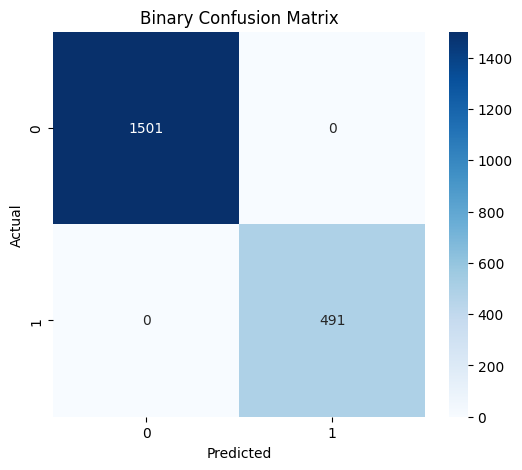


 ZERO-DAY RESULTS
Total Zero-Day Samples: 409
Detected Attacks: 409
Detection Rate: 100.00%

Model Saved 

Sample Prediction: 0
Actual: 0


In [3]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, IsolationForest
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


df = pd.read_csv(
    '/kaggle/input/datasets/shahdsameh123/binary11/wustl-ehms-2020_with_attacks_categories (5).csv',
    low_memory=False
)

print("Data Loaded ")


df = df.dropna()

df.columns = df.columns.str.replace(' ', '_')


le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))


target_col = 'Label'

df[target_col] = df[target_col].apply(
    lambda x: 0 if x == 0 else 1
)

print("\nBinary Labels:")
print(df[target_col].value_counts())


n_samples = 5000

df_balanced = (
    df.groupby(target_col, group_keys=False)
    .apply(
        lambda x: x.sample(
            n=min(len(x), n_samples),
            random_state=42
        )
    )
    .reset_index(drop=True)
)

print("\nAfter Balancing:")
print(df_balanced[target_col].value_counts())


attack_samples = df_balanced[
    df_balanced[target_col] == 1
]


zero_day_size = int(len(attack_samples) * 0.2)

df_zero = attack_samples.sample(
    n=zero_day_size,
    random_state=42
)

df_known = df_balanced.drop(df_zero.index)


X = df_known.drop(columns=[target_col])
y = df_known[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


selector = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    verbose=-1
)

selector.fit(X_train, y_train)

importances = selector.feature_importances_

top_idx = np.argsort(importances)[-15:]

top_features = X.columns[top_idx]

X_train = X_train[top_features]
X_test = X_test[top_features]
X_zero = df_zero[top_features]

print("\nTop Features:")
print(list(top_features))


rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    random_state=42
)

xgb = Pipeline([
    ('scaler', StandardScaler()),

    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        eval_metric='logloss',
        random_state=42
    ))
])

lgbm = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.03,
    num_leaves=50,
    random_state=42,
    verbose=-1
)


vote = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('lgbm', lgbm)
    ],
    voting='soft'
)

print("\nTraining Model...")

vote.fit(X_train, y_train)


y_pred = vote.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("\n" + "="*40)
print(" FINAL RESULTS")
print("="*40)

print(f"Accuracy: {acc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Binary Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


iso = IsolationForest(
    contamination=0.20,
    n_estimators=200,
    random_state=42
)

iso.fit(X_train)


vote_preds = vote.predict(X_zero)

iso_preds = iso.predict(X_zero)

final_zero_preds = []

for v, i in zip(vote_preds, iso_preds):

    if i == -1:
        final_zero_preds.append(1)

    else:
        final_zero_preds.append(v)

final_zero_preds = np.array(final_zero_preds)

detected = (final_zero_preds == 1).sum()

total = len(final_zero_preds)

detection_rate = (detected / total) * 100

print("\n" + "="*40)
print(" ZERO-DAY RESULTS")
print("="*40)

print(f"Total Zero-Day Samples: {total}")
print(f"Detected Attacks: {detected}")
print(f"Detection Rate: {detection_rate:.2f}%")


joblib.dump(vote, "WUSTL_BINARY_MODEL.pkl")

print("\nModel Saved ")


sample = X_test.iloc[0:1]

pred = vote.predict(sample)

print("\nSample Prediction:", pred[0])
print("Actual:", y_test.iloc[0])